# TT-22 — MLP Regressor: Du doan muc tieu hao nhien lieu (Auto MPG)

**Muc tieu:** du doan `mpg` (miles per gallon) tu cac dac trung ky thuat cua xe, dung
`MLPRegressor` (sklearn), roi quy doi sang L/100km de tu van khach hang chi phi
nhien lieu hang nam.

Notebook nay chay lai toan bo pipeline trong `src/train.py` theo tung buoc, kem
giai thich va bang so sanh. De chay lai tu dau, dat kernel goc thu muc du an va
chay tuan tu tu tren xuong.

In [1]:
import sys
sys.path.insert(0, "../src")
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from train import (
    load_data, clean_data, eda_plots,
    run_baselines, scale_comparison, architecture_comparison,
    plot_loss_curve, alpha_sweep, activation_comparison, final_comparison,
    mpg_to_l100km, estimate_annual_fuel_cost, RANDOM_STATE,
)
from sklearn.model_selection import train_test_split

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

## 1. Tai va lam sach du lieu

Bo du lieu **Auto MPG (UCI)**: 398 dong, 8 dac trung. `horsepower` co 6 gia tri `'?'`
(du lieu thieu), can chuyen ve so va dien median. `origin` (1=My, 2=Chau Au, 3=Nhat)
la bien phan loai nen phai one-hot, khong duoc de nguyen dang so.

Mac dinh notebook tai truc tiep tu UCI (`DATA_PATH=None`). Neu khong co mang hoac
muon dung file da tai san, dat bien moi truong `AUTO_MPG_DATA_PATH` truoc khi mo
Jupyter, hoac gan truc tiep vao `DATA_PATH` ben duoi.

In [2]:
import os
DATA_PATH = os.environ.get("AUTO_MPG_DATA_PATH")  # None -> tai truc tiep tu UCI

df_raw = load_data(DATA_PATH)
df = clean_data(df_raw)
print(df.shape)
df.head()

[clean] So gia tri '?' o horsepower da dien median: 6
(398, 10)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
0,18.000,8,307.000,130.000,"3,504.000",12.000,70,False,False,True
1,15.000,8,350.000,165.000,"3,693.000",11.500,70,False,False,True
2,18.000,8,318.000,150.000,"3,436.000",11.000,70,False,False,True
3,16.000,8,304.000,150.000,"3,433.000",12.000,70,False,False,True
4,17.000,8,302.000,140.000,"3,449.000",10.500,70,False,False,True


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,398.000,23.515,7.816,9.000,17.500,23.000,29.000,46.600
cylinders,398.000,5.455,1.701,3.000,4.000,4.000,8.000,8.000
displacement,398.000,193.426,104.270,68.000,104.250,148.500,262.000,455.000
horsepower,398.000,104.304,38.223,46.000,76.000,93.500,125.000,230.000
weight,398.000,"2,970.425",846.842,"1,613.000","2,223.750","2,803.500","3,608.000","5,140.000"
acceleration,398.000,15.568,2.758,8.000,13.825,15.500,17.175,24.800
model_year,398.000,76.010,3.698,70.000,73.000,76.000,79.000,82.000


## 2. EDA nhanh

- `weight` vs `mpg`: quan he nghich, hoi cong (khong hoan toan tuyen tinh) — day la
  ly do MLP co the thang cac mo hinh tuyen tinh don gian.
- `mpg` trung binh theo `model_year`: xe cang doi moi cang tiet kiem nhien lieu hon
  (cong nghe dong co cai thien qua thoi gian).

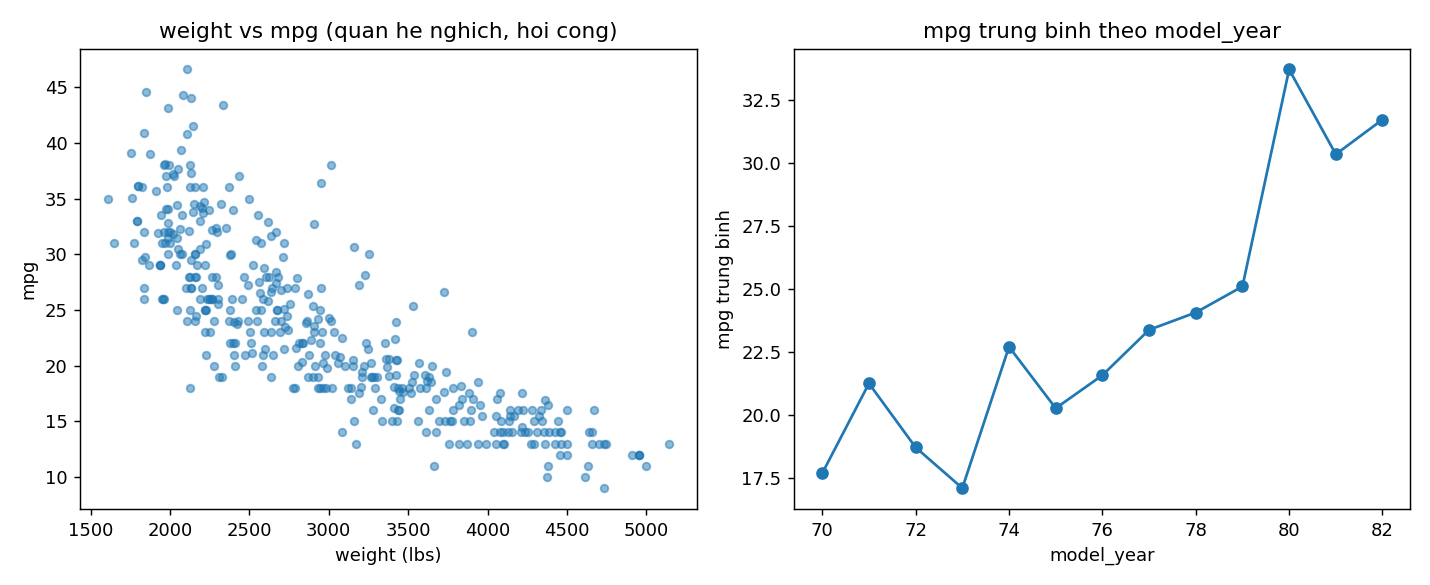

In [4]:
eda_plots(df)
display(Image(filename="../reports/eda_overview.png"))

## 3. Chia tap train/test

In [5]:
X = df.drop(columns=["mpg"])
y = df["mpg"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
X_train.shape, X_test.shape

((318, 9), (80, 9))

## 4. Baseline: Dummy / Linear Regression / Random Forest

Truoc khi dung mang no-ron, can biet "san" hieu nang cua cac mo hinh don gian hon.

In [6]:
baselines = run_baselines(X_train, y_train, X_test, y_test)
pd.DataFrame(baselines).T

,rmse_train,rmse_test,r2_test,train_time_s
Dummy (mean),7.918,7.347,-0.004,0.000
Linear Regression,3.370,2.888,0.845,0.002
Random Forest,1.082,2.169,0.912,0.417


## 5–6. MLP: khong scale vs chi scale X vs scale ca X va y

MLP la mo hinh dua tren gradient descent nen **rat nhay voi thang do dau vao**.
Neu khong scale, cac trong so ban dau se khong phu hop voi bien do du lieu (vd
`weight` ~ hang nghin trong khi `acceleration` ~ hang chuc) → hoi tu cham hoac
khong hoi tu. Scale ca nhan `y` giup mang hoi tu tot hon vi target quanh 0.

In [7]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scale_results, best_scaled_model = scale_comparison(X_train, y_train, X_test, y_test)
pd.DataFrame(scale_results).T

,rmse_train,rmse_test,r2_test,train_time_s
Khong scale,3.830,3.146,0.816,0.199
Chi scale X,2.538,2.222,0.908,0.514
Scale ca X va y,2.020,2.123,0.916,0.289


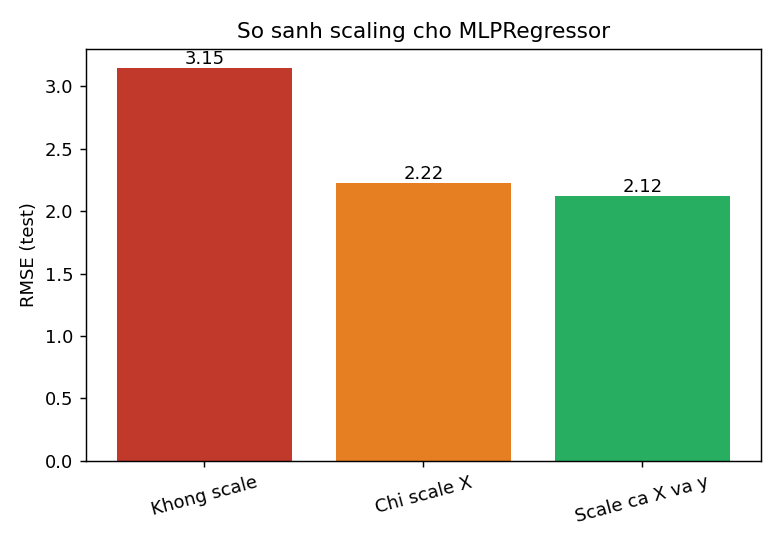

In [8]:
display(Image(filename="../reports/scale_comparison.png"))

## 7. So sanh 4 kien truc — minh chung overfit tren du lieu nho

Chi co 398 mau — mot mang qua lon (`(256,128,64)`, hang chuc nghin tham so) de
overfit ngay ca khi da co `alpha` va `early_stopping`. Cot `overfit_gap` = RMSE_test
− RMSE_train; gap duong lon la dau hieu overfit.

In [9]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    arch_results = architecture_comparison(X_train, y_train, X_test, y_test)
arch_df = pd.DataFrame(arch_results).T
arch_df

,rmse_train,rmse_test,r2_test,train_time_s,n_params,overfit_gap
(16),2.757,2.457,0.888,0.304,177.000,-0.300
(64),2.636,2.229,0.908,0.149,705.000,-0.407
"(64,32)",2.020,2.123,0.916,0.265,"2,753.000",0.104
"(256,128,64)",2.113,2.295,0.902,0.343,"43,777.000",0.182


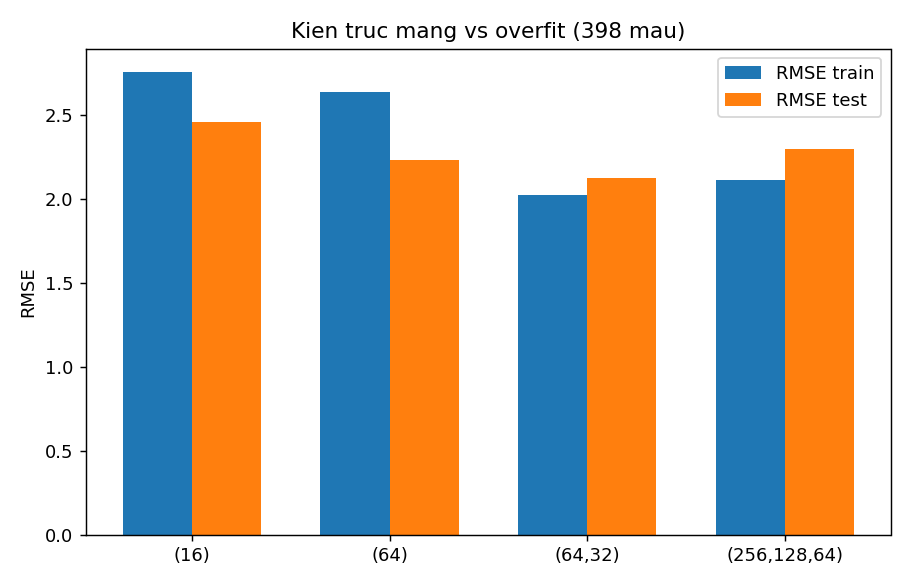

Kien truc tot nhat tren test: (64,32)


In [10]:
display(Image(filename="../reports/kien_truc_overfit.png"))
best_arch_name = arch_df["rmse_test"].astype(float).idxmin()
print("Kien truc tot nhat tren test:", best_arch_name)

## 8. loss_curve_ va validation_scores_ cua model tot nhat

`loss_curve_` la loss huan luyen qua tung epoch; `validation_scores_` la diem R^2
tren tap validation noi bo (dung de kich hoat `early_stopping`). Neu validation
score ngung cai thien ma loss train van giam → dau hieu bat dau overfit.

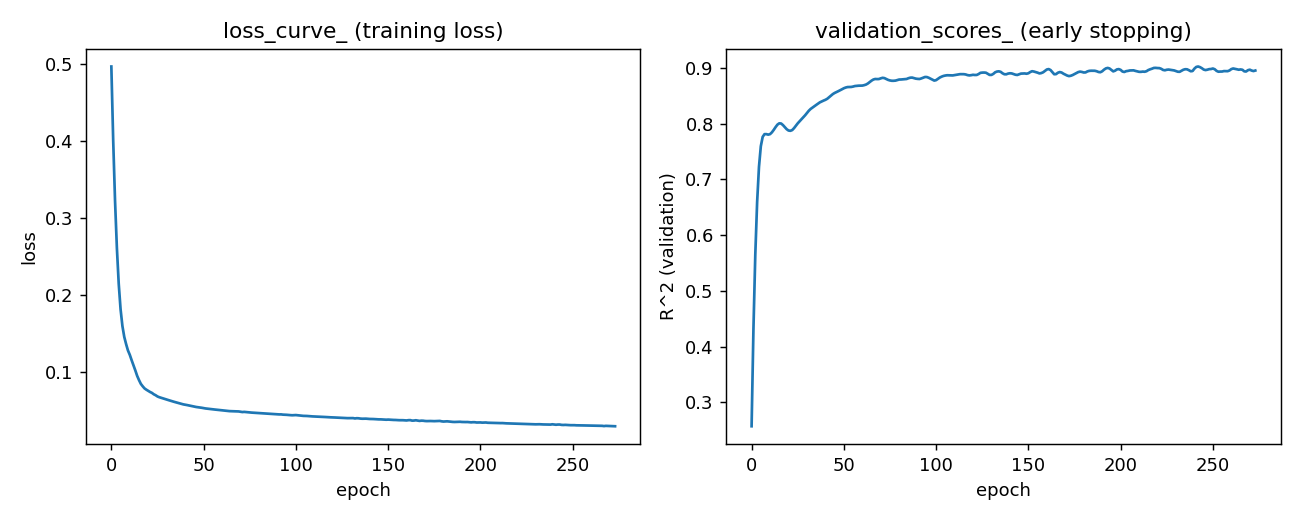

In [11]:
plot_loss_curve(best_scaled_model)
display(Image(filename="../reports/loss_curve.png"))

## 9. Do `alpha` (regularization)

`alpha` la he so phat L2 len trong so mang. `alpha` qua nho → de overfit; qua lon
→ underfit. Ta do tren luoi {1e-4, 1e-3, 1e-2, 1e-1}.

In [12]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    alpha_results = alpha_sweep(X_train, y_train, X_test, y_test)
alpha_df = pd.DataFrame(alpha_results).T
alpha_df

,rmse_train,rmse_test,r2_test,train_time_s
0.0001,2.094,2.121,0.916,0.254
0.001,2.096,2.115,0.917,0.244
0.01,2.020,2.123,0.916,0.313
0.1,2.113,2.081,0.919,0.270


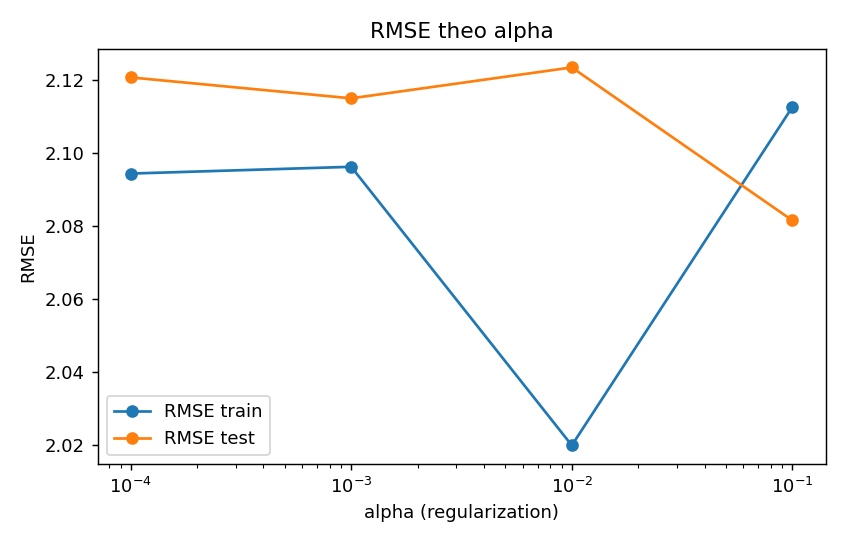

Alpha tot nhat tren test: 0.1


In [13]:
display(Image(filename="../reports/alpha_sweep.png"))
best_alpha = float(alpha_df["rmse_test"].astype(float).idxmin())
print("Alpha tot nhat tren test:", best_alpha)

## 10. So sanh activation: relu / tanh / logistic

In [14]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    act_results = activation_comparison(X_train, y_train, X_test, y_test)
pd.DataFrame(act_results).T

,rmse_train,rmse_test,r2_test,train_time_s
relu,2.020,2.123,0.916,0.275
tanh,2.349,1.975,0.927,0.326
logistic,3.664,2.938,0.839,0.111


## 11. Bang so sanh cuoi cung: Linear Regression vs Random Forest vs SVR vs MLPRegressor

Ca 4 thuat toan duoc huan luyen tren cung mot tap train/test de so sanh cong bang
tren tieu chi RMSE, thoi gian train, va muc do giai thich duoc.

In [15]:
arch_map = {"(16)": (16,), "(64)": (64,), "(64,32)": (64, 32), "(256,128,64)": (256, 128, 64)}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_results = final_comparison(
        X_train, y_train, X_test, y_test,
        best_mlp_config=(arch_map[best_arch_name], best_alpha),
    )
final_df = pd.DataFrame(final_results).T
final_df

,rmse_train,rmse_test,r2_test,train_time_s
Linear Regression,3.370,2.888,0.845,0.005
Random Forest,1.082,2.169,0.912,0.407
SVR,2.261,1.950,0.929,0.008
MLPRegressor,2.113,2.081,0.919,0.277


**Nhan xet giai thich duoc:**
- *Linear Regression*: he so co the doc truc tiep (vd moi 1000 lbs weight tang thi
  mpg giam bao nhieu) — de giai thich nhat.
- *Random Forest*: co `feature_importances_`, giai thich duoc o muc trung binh.
- *SVR* / *MLPRegressor*: gan nhu hop den, chi giai thich duoc qua cac ky thuat
  hau ky (permutation importance, SHAP...), khong doc truc tiep tu trong so.

## 12. Quy doi ket qua sang L/100km va uoc tinh chi phi xang/nam

Cong thuc: `L/100km = 235.215 / mpg`. Vi du voi mot xe trong tap test và gia
xang gia dinh 21.000 VND/L, chay 15.000 km/nam.

In [16]:
final_model = best_scaled_model  # model (64,32), scale X&y — xap xi model cuoi trong src/train.py

sample = X_test.iloc[[0]]
pred_mpg = float(final_model.predict(sample)[0])
l100 = mpg_to_l100km(pred_mpg)
annual_cost = estimate_annual_fuel_cost(l100)

print(f"Du doan: {pred_mpg:.1f} mpg  ~=  {l100:.1f} L/100km")
print(f"Uoc tinh chi phi xang/nam (15.000 km, 21.000 VND/L): {annual_cost:,.0f} VND")

Du doan: 33.8 mpg  ~=  7.0 L/100km
Uoc tinh chi phi xang/nam (15.000 km, 21.000 VND/L): 21,952,672 VND


## 13. Ket luan trung thuc

Tren bo du lieu bang **chi 398 dong**, MLPRegressor dat hieu nang **xap xi hoac
chi nhinh hon rat it** so voi Random Forest / SVR (xem bang so sanh o Muc 11),
trong khi:

- Can nhieu buoc tien xu ly hon (bat buoc scale X va y, dò alpha, chon kien truc).
- Khong on dinh giua cac lan chay bang cay quyet dinh / rung ngau nhien (nhay voi
  khoi tao trong so, thu tu du lieu).
- Kho giai thich hon nhieu so voi Linear Regression hay Random Forest.

**Khuyen nghi:** voi du lieu bang co kich thuoc nho-trung binh nhu Auto MPG, cay
quyet dinh / ensemble (Random Forest, Gradient Boosting) thuong la lua chon thuc
te hon MLP. MLP chi thuc su co loi the ro rang khi du lieu lon hon nhieu (xem muc
"Mo rong" trong README — thu voi bo Bike Sharing ~17k dong) hoac quan he giua cac
bien that su rat phi tuyen ma cay kho nam bat.